## This notebook is for cleaning up previous code, so you can input parameters, and then outputs the $H(\phi), C(\phi)$ 
## First make sure the uncouopled system is a limit cycle

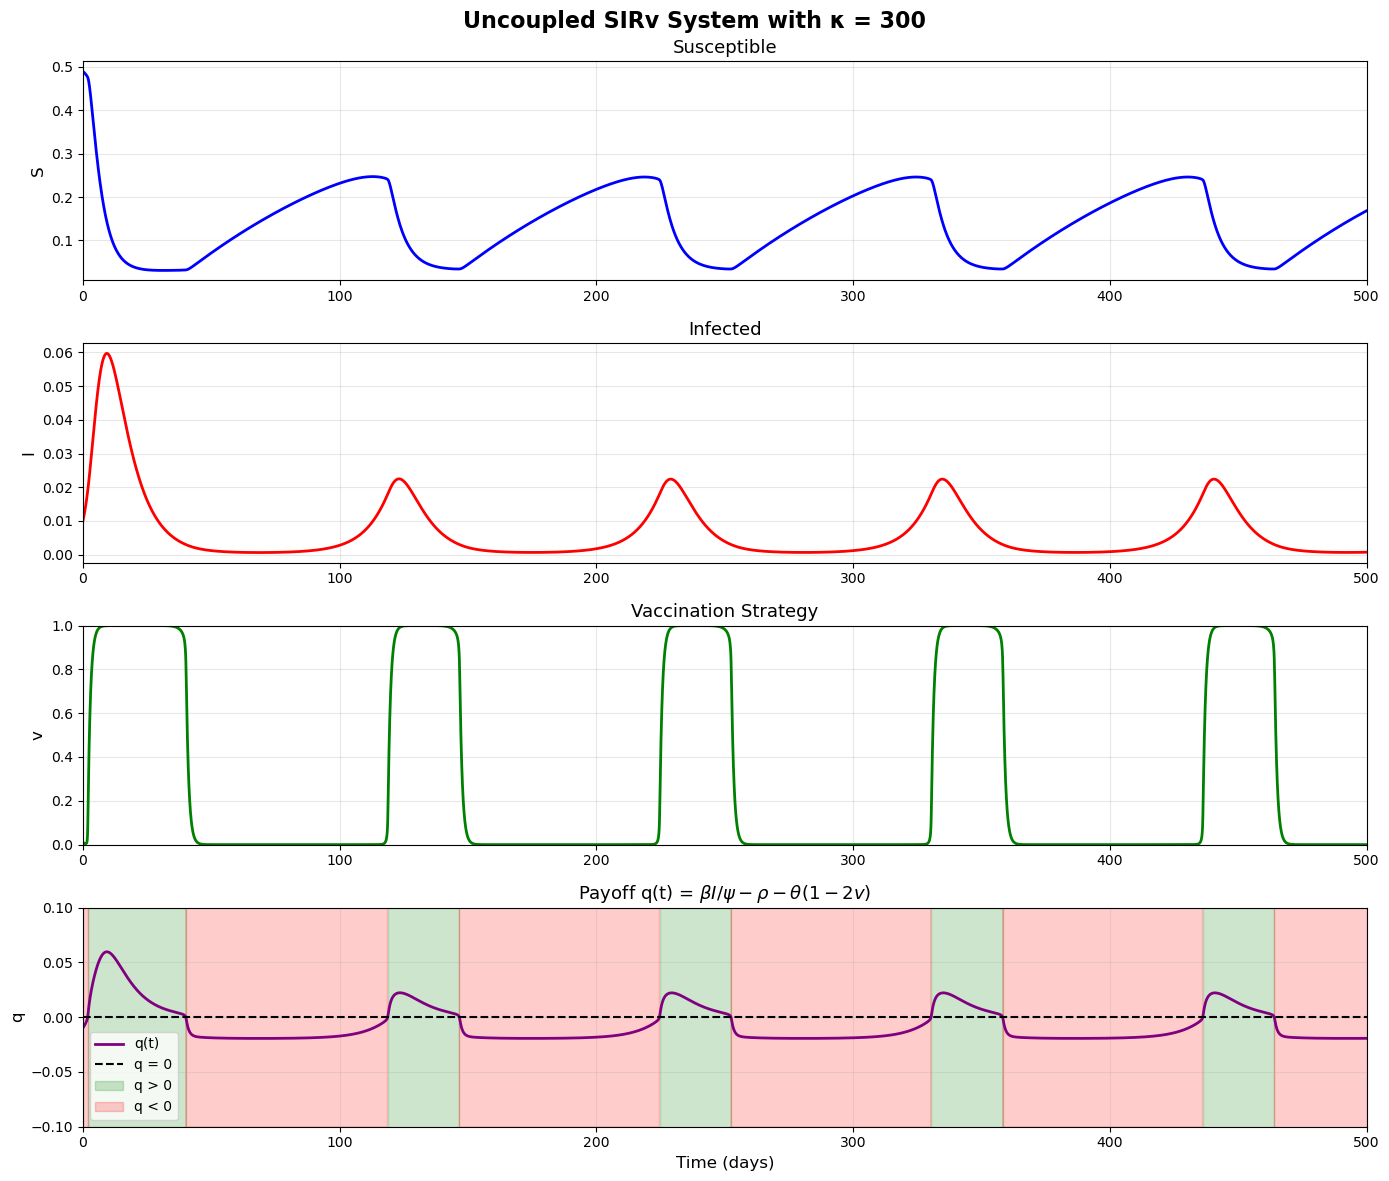

SIMULATION RESULTS (κ = 1000)

Final values at t = 500.0 days:
S = 0.168432
I = 0.000717
v = 0.000000
q = -0.01928294

PAYOFF q STATISTICS
Mean q: -0.00715640
Min q: -0.01938213
Max q: 0.05971308
Std q: 0.01701970
Fraction of time q > 0: 0.2994
Fraction of time q < 0: 0.7006


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def uncoupled_smooth_sirv(t, y, alpha, beta, gamma, eta, theta, kappa, rho, psi):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]

# Parameters
params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.01,
    'kappa': 1000,  # Changed from 1000 to 100
    'rho': 0.01,
    'psi': 0.5
}

# Initial conditions: [S0, I0, v0]
y0 = [0.49, 0.01, 0.01]

# Time span
t_span = (0, 500)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Solve the system
sol = solve_ivp(
    uncoupled_smooth_sirv,
    t_span,
    y0,
    args=(params['alpha'], params['beta'], params['gamma'], params['eta'],
          params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

S, I, v = sol.y

# Calculate payoff q(t)
q_t = params['beta']*(I/params['psi']) - params['rho'] - params['theta']*(1 - 2*v)

# Create plots
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle(r'Uncoupled SIRv System with κ = 300', fontsize=16, fontweight='bold')

# Plot S
axes[0].plot(sol.t, S, 'b-', linewidth=2)
axes[0].set_ylabel('S', fontsize=12)
axes[0].set_title('Susceptible', fontsize=13)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 500)

# Plot I
axes[1].plot(sol.t, I, 'r-', linewidth=2)
axes[1].set_ylabel('I', fontsize=12)
axes[1].set_title('Infected', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, 500)

# Plot v
axes[2].plot(sol.t, v, 'g-', linewidth=2)
axes[2].set_ylabel('v', fontsize=12)
axes[2].set_title('Vaccination Strategy', fontsize=13)
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, 500)

# Plot q(t)
axes[3].plot(sol.t, q_t, 'purple', linewidth=2, label='q(t)')
axes[3].axhline(y=0, color='k', linestyle='--', linewidth=1.5, label='q = 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t >= 0), 
                     alpha=0.2, color='green', label='q > 0')
axes[3].fill_between(sol.t, -0.1, 0.1, where=(q_t < 0), 
                     alpha=0.2, color='red', label='q < 0')
axes[3].set_ylabel('q', fontsize=12)
axes[3].set_xlabel('Time (days)', fontsize=12)
axes[3].set_title(r'Payoff q(t) = $\beta I/\psi - \rho - \theta(1-2v)$', fontsize=13)
axes[3].set_ylim(-0.1, 0.1)
axes[3].set_xlim(0, 500)
axes[3].legend(fontsize=10, loc='best')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print(f"SIMULATION RESULTS (κ = {params['kappa']})")
print("="*80)
print(f"\nFinal values at t = {sol.t[-1]:.1f} days:")
print(f"S = {S[-1]:.6f}")
print(f"I = {I[-1]:.6f}")
print(f"v = {v[-1]:.6f}")
print(f"q = {q_t[-1]:.8f}")

print("\n" + "="*80)
print("PAYOFF q STATISTICS")
print("="*80)
print(f"Mean q: {np.mean(q_t):.8f}")
print(f"Min q: {np.min(q_t):.8f}")
print(f"Max q: {np.max(q_t):.8f}")
print(f"Std q: {np.std(q_t):.8f}")
print(f"Fraction of time q > 0: {np.sum(q_t > 0) / len(q_t):.4f}")
print(f"Fraction of time q < 0: {np.sum(q_t < 0) / len(q_t):.4f}")

## Confirm if they synchronize

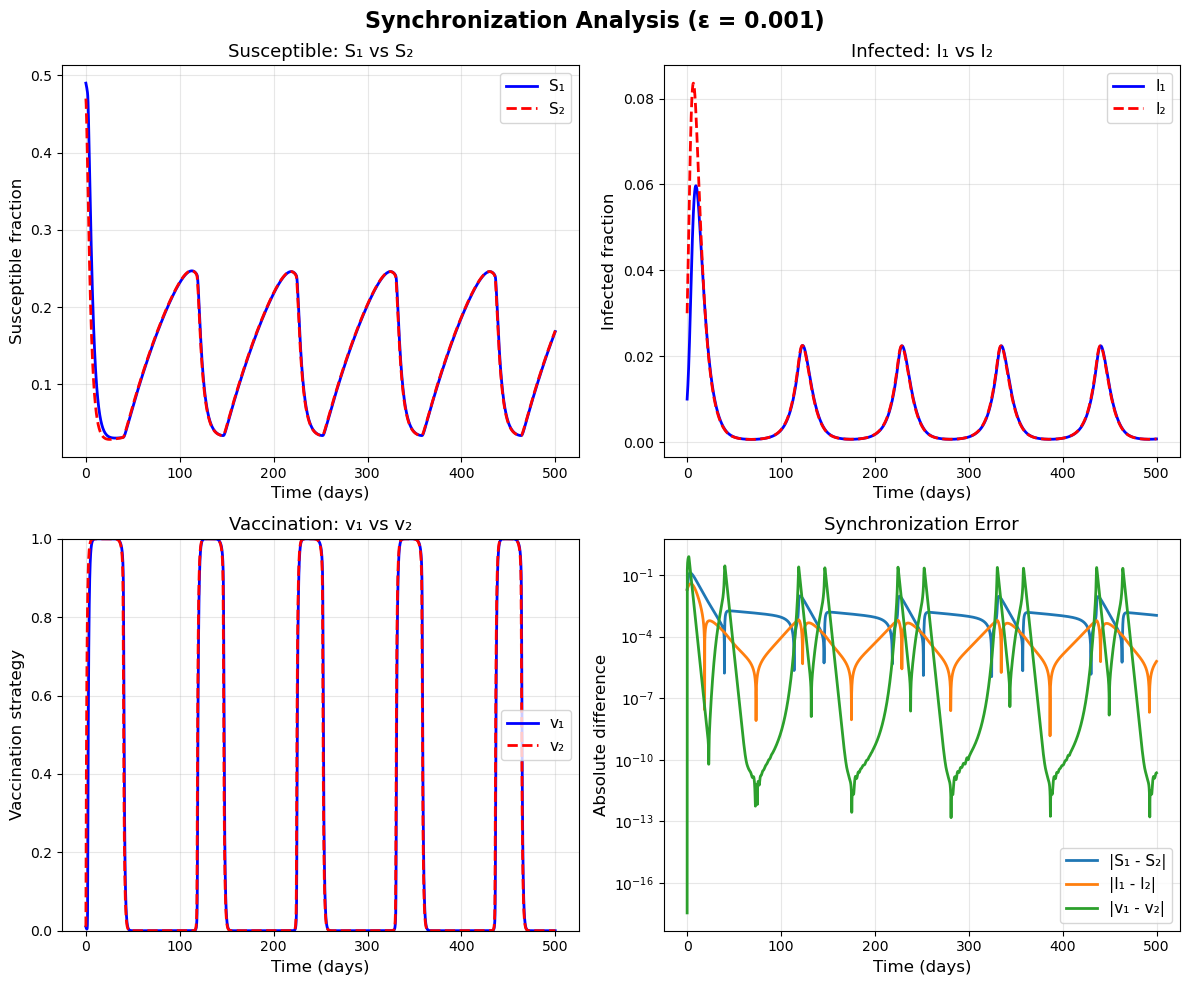


Synchronization Analysis at t = 500.0 days:
Final |S₁ - S₂| = 0.001093
Final |I₁ - I₂| = 0.000006
Final |v₁ - v₂| = 0.000000

Mean absolute differences over time:
Mean |S₁ - S₂| = 0.003650
Mean |I₁ - I₂| = 0.000811
Mean |v₁ - v₂| = 0.010290


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the coupled system
def coupled_sirv(t, y, alpha, beta, gamma, epsilon, eta, theta, kappa, rho, psi):
    """
    Coupled SIRv system with social influence
    y = [S1, I1, v1, S2, I2, v2]
    """
    S1, I1, v1, S2, I2, v2 = y
    
    # Group 1 dynamics
    dS1 = alpha*(psi - S1 - I1) - beta*S1*(I1/psi) - eta*v1*S1
    dI1 = -gamma*I1 + beta*S1*(I1/psi)
    dv1 = -v1 + 1/(1 + np.exp(-kappa*(beta*I1/psi - rho - theta*(1 - 2*((1-epsilon)*v1 + epsilon*v2)))))
    
    # Group 2 dynamics
    dS2 = alpha*(1 - psi - S2 - I2) - beta*S2*(I2/(1-psi)) - eta*v2*S2
    dI2 = -gamma*I2 + beta*S2*(I2/(1-psi))
    dv2 = -v2 + 1/(1 + np.exp(-kappa*(beta*I2/(1-psi) - rho - theta*(1 - 2*((1-epsilon)*v2 + epsilon*v1)))))
    
    return [dS1, dI1, dv1, dS2, dI2, dv2]

# Default parameters
params = {
    'alpha': 0.01,      # 1/day - loss of immunity
    'beta': 0.5,        # 1/day - transmission rate
    'gamma': 1/7,       # 1/day - recovery rate
    'epsilon': 0.001,     # coupling parameter (you can adjust this)
    'eta': 1/7,         # 1/day - vaccination appointment rate
    'theta': 0.01,      # relational cost
    'kappa': 1000,      # payoff sensitivity
    'rho': 0.01,        # risk of vaccine morbidity
    'psi': 0.5          # proportion in group 1
}

# Initial conditions: (S1, I1, v1, S2, I2, v2)
y0 = [0.49, 0.01, 0.01, 0.47, 0.03, 0.01]

# Time span
t_span = (0, 500)  # days
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# Solve the system
sol = solve_ivp(
    coupled_sirv, 
    t_span, 
    y0, 
    args=(params['alpha'], params['beta'], params['gamma'], params['epsilon'], 
          params['eta'], params['theta'], params['kappa'], params['rho'], params['psi']),
    t_eval=t_eval,
    method='LSODA',
    rtol=1e-8,
    atol=1e-10
)

# Extract solutions
S1, I1, v1, S2, I2, v2 = sol.y

# Create synchronization comparison plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Synchronization Analysis (ε = {params["epsilon"]})', fontsize=16, fontweight='bold')

# S1 vs S2
axes[0, 0].plot(sol.t, S1, 'b-', label='S₁', linewidth=2)
axes[0, 0].plot(sol.t, S2, 'r--', label='S₂', linewidth=2)
axes[0, 0].set_xlabel('Time (days)', fontsize=12)
axes[0, 0].set_ylabel('Susceptible fraction', fontsize=12)
axes[0, 0].set_title('Susceptible: S₁ vs S₂', fontsize=13)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# I1 vs I2
axes[0, 1].plot(sol.t, I1, 'b-', label='I₁', linewidth=2)
axes[0, 1].plot(sol.t, I2, 'r--', label='I₂', linewidth=2)
axes[0, 1].set_xlabel('Time (days)', fontsize=12)
axes[0, 1].set_ylabel('Infected fraction', fontsize=12)
axes[0, 1].set_title('Infected: I₁ vs I₂', fontsize=13)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# v1 vs v2
axes[1, 0].plot(sol.t, v1, 'b-', label='v₁', linewidth=2)
axes[1, 0].plot(sol.t, v2, 'r--', label='v₂', linewidth=2)
axes[1, 0].set_xlabel('Time (days)', fontsize=12)
axes[1, 0].set_ylabel('Vaccination strategy', fontsize=12)
axes[1, 0].set_title('Vaccination: v₁ vs v₂', fontsize=13)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1])

# Difference measures
axes[1, 1].plot(sol.t, np.abs(S1 - S2), label='|S₁ - S₂|', linewidth=2)
axes[1, 1].plot(sol.t, np.abs(I1 - I2), label='|I₁ - I₂|', linewidth=2)
axes[1, 1].plot(sol.t, np.abs(v1 - v2), label='|v₁ - v₂|', linewidth=2)
axes[1, 1].set_xlabel('Time (days)', fontsize=12)
axes[1, 1].set_ylabel('Absolute difference', fontsize=12)
axes[1, 1].set_title('Synchronization Error', fontsize=13)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# Print synchronization metrics
print(f"\nSynchronization Analysis at t = {sol.t[-1]:.1f} days:")
print(f"Final |S₁ - S₂| = {abs(S1[-1] - S2[-1]):.6f}")
print(f"Final |I₁ - I₂| = {abs(I1[-1] - I2[-1]):.6f}")
print(f"Final |v₁ - v₂| = {abs(v1[-1] - v2[-1]):.6f}")
print(f"\nMean absolute differences over time:")
print(f"Mean |S₁ - S₂| = {np.mean(np.abs(S1 - S2)):.6f}")
print(f"Mean |I₁ - I₂| = {np.mean(np.abs(I1 - I2)):.6f}")
print(f"Mean |v₁ - v₂| = {np.mean(np.abs(v1 - v2)):.6f}")

## Now calculate $H(\phi)$. Note that the calculation of $H(\phi)$ does not involve $\epsilon$, and $\epsilon$, given small enough that we actually have weak coupling, would only influence the speed of convergence, not the *nature* of its equilibrium

State after transients: S=0.048355, I=0.011948, v=0.999997
Period T = 105.796000 days
Computed γ'(t) = F(γ(t)) along the limit cycle
Computed σ'(ξ(t)) along the limit cycle
  σ' ranges from 2.239697e-10 to 2.499946e-01
Created periodic interpolation for v(t)

Computed H(φ) at 200 points
  H ranges from -3.043224e-03 to 5.754579e-02

H(φ) stored in H container

Computed C(φ) = H(-φ) - H(φ)
  C ranges from -6.058847e-02 to 6.058847e-02

PHASE-LOCKED STATES

  φ = 0.0000 days (θ = 0.0000 rad = 0.0°)
    C'(φ) = -6.560747e-03
    STABLE

  φ = 41.7756 days (θ = 2.4810 rad = 142.2°)
    C'(φ) = 9.718872e-09
    UNSTABLE

  φ = 52.8980 days (θ = 3.1416 rad = 180.0°)
    C'(φ) = -5.630191e-10
    STABLE

  φ = 64.0204 days (θ = 3.8021 rad = 217.8°)
    C'(φ) = 9.718872e-09
    UNSTABLE


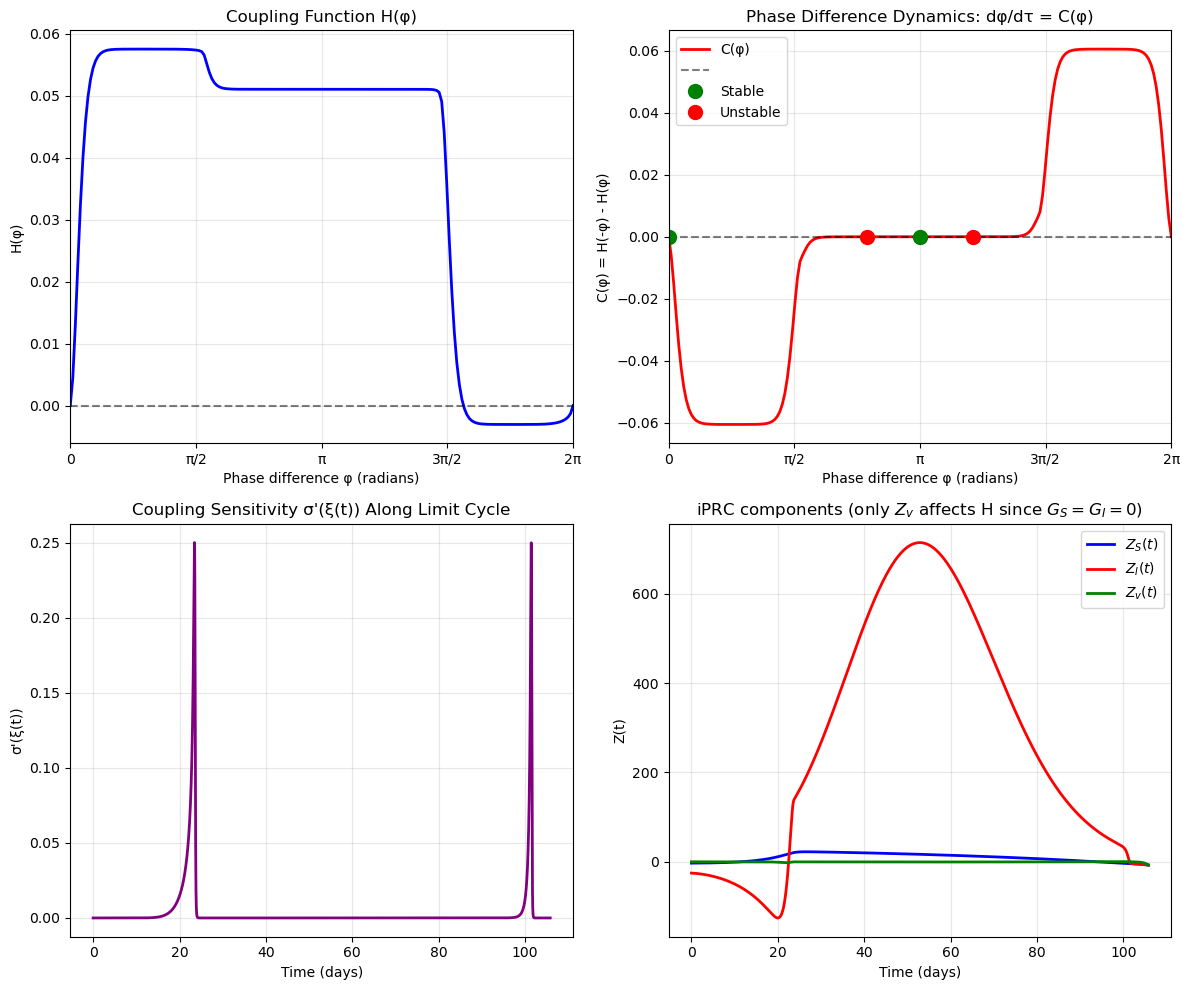


SUMMARY
Period T = 105.7960 days
ω = 2π/T = 0.059390 rad/day

Coupling function H(φ) computed
Phase dynamics: dφ/dτ = H(-φ) - H(φ) = C(φ)

Phase-locked states occur where C(φ) = 0
  - Stable if C'(φ) < 0 (green dots)
  - Unstable if C'(φ) > 0 (red dots)


In [20]:
"""
Find the limit cycle (periodic orbit) for the uncoupled smooth SIRv system.

This script:
1. Integrates the system for a long time to reach the attractor
2. Detects the period using Poincaré section crossings
3. Extracts one complete cycle γ(t) = [S(t), I(t), v(t)]
4. Verifies periodicity
"""

import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


# =============================================================================
# SYSTEM DEFINITION
# =============================================================================

def uncoupled_smooth_sirv(t, y, params):
    """
    Uncoupled smooth SIRv system (epsilon = 0)
    y = [S, I, v]
    """
    S, I, v = y
    alpha = params['alpha']
    beta = params['beta']
    gamma = params['gamma']
    eta = params['eta']
    theta = params['theta']
    kappa = params['kappa']
    rho = params['rho']
    psi = params['psi']
    
    dS = alpha*(psi - S - I) - beta*S*(I/psi) - eta*v*S
    dI = -gamma*I + beta*S*(I/psi)
    dv = -v + 1/(1 + np.exp(-kappa*(beta*I/psi - rho - theta*(1 - 2*v))))
    
    return [dS, dI, dv]


# =============================================================================
# PARAMETERS
# =============================================================================

params = {
    'alpha': 0.01,
    'beta': 0.5,
    'gamma': 1/7,
    'eta': 1/7,
    'theta': 0.01,
    'kappa': 1000,
    'rho': 0.01,
    'psi': 0.5
}

y0 = [0.49, 0.01, 0.01]  # Initial conditions [S0, I0, v0]


# =============================================================================
# STEP 1: INTEGRATE PAST TRANSIENTS
# =============================================================================

t_transient = 5000

sol_transient = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params),
    [0, t_transient],
    y0,
    method='RK45',
    rtol=1e-10,
    atol=1e-12
)

y_after_transient = sol_transient.y[:, -1]
print(f"State after transients: S={y_after_transient[0]:.6f}, "
      f"I={y_after_transient[1]:.6f}, v={y_after_transient[2]:.6f}")


# =============================================================================
# STEP 2: FIND THE PERIOD
# =============================================================================

t_cycle_search = 2000
dt = 0.01
t_eval = np.arange(0, t_cycle_search, dt)

sol_search = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params),
    [0, t_cycle_search],
    y_after_transient,
    method='RK45',
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

# Find peaks in I to determine period
I_data = sol_search.y[1, :]
peaks, _ = find_peaks(I_data, height=np.mean(I_data), distance=int(1/dt))

peak_times = sol_search.t[peaks]
periods = np.diff(peak_times)
T = np.mean(periods[-5:])  # Average of last 5 periods

print(f"Period T = {T:.6f} days")


# =============================================================================
# STEP 3: EXTRACT ONE COMPLETE CYCLE
# =============================================================================

# Start from a peak (phase = 0 at peak I)
start_idx = peaks[-2]
y_cycle_start = sol_search.y[:, start_idx]

# Integrate for exactly one period
n_points = 10000
t_cycle = np.linspace(0, T, n_points)

sol_cycle = solve_ivp(
    lambda t, y: uncoupled_smooth_sirv(t, y, params),
    [0, T],
    y_cycle_start,
    method='RK45',
    t_eval=t_cycle,
    rtol=1e-12,
    atol=1e-14
)


# =============================================================================
# STEP 4: STORE THE LIMIT CYCLE AS Gamma
# =============================================================================

class Gamma:
    """
    Container for the limit cycle γ(t) = [S(t), I(t), v(t)]
    
    Usage:
        Gamma.t    - time array [0, T]
        Gamma.S    - S(t) along the cycle
        Gamma.I    - I(t) along the cycle
        Gamma.v    - v(t) along the cycle
        Gamma.T    - period
        Gamma.y    - full state array, shape (3, n_points)
    """
    t = sol_cycle.t
    S = sol_cycle.y[0, :]
    I = sol_cycle.y[1, :]
    v = sol_cycle.y[2, :]
    T = T
    y = sol_cycle.y  # [S, I, v] stacked


# =============================================================================
# COMPUTE THE JACOBIAN DF USING SYMPY
# =============================================================================

import sympy as sp

# Define symbolic variables
S_sym, I_sym, v_sym = sp.symbols('S I v')
alpha_sym, beta_sym, gamma_sym, eta_sym = sp.symbols('alpha beta gamma eta')
theta_sym, kappa_sym, rho_sym, psi_sym = sp.symbols('theta kappa rho psi')

# Define the vector field F = [F1, F2, F3]
F1 = alpha_sym*(psi_sym - S_sym - I_sym) - beta_sym*S_sym*(I_sym/psi_sym) - eta_sym*v_sym*S_sym
F2 = -gamma_sym*I_sym + beta_sym*S_sym*(I_sym/psi_sym)
F3 = -v_sym + 1/(1 + sp.exp(-kappa_sym*(beta_sym*I_sym/psi_sym - rho_sym - theta_sym*(1 - 2*v_sym))))

F = sp.Matrix([F1, F2, F3])
state = sp.Matrix([S_sym, I_sym, v_sym])

# Compute Jacobian symbolically
DF_symbolic = F.jacobian(state)


# Convert to numerical function
param_symbols = (alpha_sym, beta_sym, gamma_sym, eta_sym, theta_sym, kappa_sym, rho_sym, psi_sym)
all_symbols = (S_sym, I_sym, v_sym) + param_symbols

DF_func = sp.lambdify(all_symbols, DF_symbolic, modules='numpy')


def compute_DF(S, I, v, params):
    """
    Compute the Jacobian matrix DF at a point (S, I, v).
    
    Returns:
        DF : 3x3 numpy array
    """
    return np.array(DF_func(
        S, I, v,
        params['alpha'], params['beta'], params['gamma'], params['eta'],
        params['theta'], params['kappa'], params['rho'], params['psi']
    ))

# =============================================================================
# COMPUTE A(t) = DF(Gamma(t)) ALONG THE LIMIT CYCLE
# =============================================================================

n_points = len(Gamma.t)
A = np.zeros((n_points, 3, 3))

for i in range(n_points):
    A[i] = compute_DF(Gamma.S[i], Gamma.I[i], Gamma.v[i], params)
# =============================================================================
# COMPUTE Z(t) BY BACKWARD INTEGRATION OF THE ADJOINT EQUATION
# =============================================================================

from scipy.interpolate import interp1d

# -----------------------------------------------------------------------------
# Step 1: Compute γ'(t) = F(γ(t)) along the limit cycle
# -----------------------------------------------------------------------------

# γ'(t) is just the vector field evaluated along the cycle
Gamma_dot = np.zeros((3, n_points))
for i in range(n_points):
    Gamma_dot[:, i] = uncoupled_smooth_sirv(Gamma.t[i], Gamma.y[:, i], params)

# Store in Gamma for convenience
Gamma.S_dot = Gamma_dot[0, :]
Gamma.I_dot = Gamma_dot[1, :]
Gamma.v_dot = Gamma_dot[2, :]
Gamma.y_dot = Gamma_dot

print("Computed γ'(t) = F(γ(t)) along the limit cycle")


# -----------------------------------------------------------------------------
# Step 2: Create interpolation functions for A(t)
# -----------------------------------------------------------------------------

# We need A(t) at arbitrary times for the ODE solver
# interp1d creates a function that interpolates between data points
# axis=0 means we interpolate along the first axis (time)
A_interp = interp1d(Gamma.t, A, axis=0, kind='linear', fill_value='extrapolate')


# -----------------------------------------------------------------------------
# Step 3: Define the adjoint equation dZ/dt = -A(t)^T @ Z
# -----------------------------------------------------------------------------

def adjoint_equation(t, Z, A_interp):
    """
    The adjoint equation: dZ/dt = -A(t)^T @ Z
    
    For backward integration, we'll use a time reversal trick:
    Let s = T - t (so s goes forward from 0 to T as t goes backward from T to 0)
    Then dZ/ds = -dZ/dt = A(t)^T @ Z = A(T-s)^T @ Z
    """
    A_t = A_interp(t)
    return -A_t.T @ Z


def adjoint_equation_reversed(s, Z, A_interp, T):
    """
    Time-reversed adjoint equation for forward integration.
    
    s = T - t, so t = T - s
    dZ/ds = A(T-s)^T @ Z
    
    This lets us use a standard forward integrator.
    """
    t = T - s
    A_t = A_interp(t)
    return A_t.T @ Z


# -----------------------------------------------------------------------------
# Step 4: Backward integration
# -----------------------------------------------------------------------------

# Initial condition: random vector (will be normalized later)
# We start at t = T and integrate backward to t = 0
Z_initial = np.array([1.0, 1.0, 1.0])

# Method 1: Direct backward integration (t goes from T to 0)
# solve_ivp can integrate backward if t_span = [T, 0]
s_eval = np.linspace(0, Gamma.T, n_points)  # s from 0 to T (forward in s)

sol_adjoint = solve_ivp(
    lambda s, Z: adjoint_equation_reversed(s, Z, A_interp, Gamma.T),
    [0, Gamma.T],
    Z_initial,
    method='RK45',
    t_eval=s_eval,
    rtol=1e-10,
    atol=1e-12
)

# Convert back: s = T - t, so t = T - s
# When s = 0, t = T (end of cycle)
# When s = T, t = 0 (start of cycle)
# So we need to flip the solution to get Z(t) with t from 0 to T
Z_raw = sol_adjoint.y[:, ::-1]  # Flip to get Z(t) with t from 0 to T

# -----------------------------------------------------------------------------
# Step 5: Normalize so that Z(t) · γ'(t) = 2π/T
# -----------------------------------------------------------------------------

omega = 2 * np.pi / Gamma.T  # angular frequency

# Compute Z · γ' at each point
Z_dot_Gamma_dot = np.sum(Z_raw * Gamma_dot, axis=0)

# Normalize: scale Z so that Z · γ' = 2π/T
# If Z_raw · γ' = c, then we want (Z_raw / c) * ω · γ' = ω
# So Z = Z_raw * (ω / c) = Z_raw * ω / (Z · γ')
Z_normalized = Z_raw * omega / Z_dot_Gamma_dot


# -----------------------------------------------------------------------------
# Step 6: Store Z(t) in a clean container
# -----------------------------------------------------------------------------

class Z_solution:
    """
    Container for the adjoint solution Z(t) = [Z_S(t), Z_I(t), Z_v(t)]
    
    This is the infinitesimal Phase Response Curve (iPRC).
    
    Usage:
        Z.t    - time array [0, T]
        Z.S    - Z_S(t), sensitivity to perturbations in S
        Z.I    - Z_I(t), sensitivity to perturbations in I
        Z.v    - Z_v(t), sensitivity to perturbations in v
        Z.y    - full solution array, shape (3, n_points)
    """
    t = Gamma.t
    S = Z_normalized[0, :]
    I = Z_normalized[1, :]
    v = Z_normalized[2, :]
    y = Z_normalized
    T = Gamma.T

Z = Z_solution()

# =============================================================================
# COMPUTE THE COUPLING FUNCTION H(φ)
# =============================================================================

# -----------------------------------------------------------------------------
# Step 1: Define the coupling function G(X1, X2)
# -----------------------------------------------------------------------------

def compute_sigma_prime_along_cycle(Gamma, params):
    """
    Compute σ'(ξ(t)) along the limit cycle, where:
        ξ(t) = κ(β I(t)/ψ - ρ - θ(1 - 2v(t)))
        σ'(ξ) = σ(ξ)(1 - σ(ξ))
    
    Returns:
        sigma_prime : array of σ'(ξ(t)) at each time point
    """
    kappa = params['kappa']
    beta = params['beta']
    psi = params['psi']
    rho = params['rho']
    theta = params['theta']
    
    # ξ(t) along the cycle
    xi = kappa * (beta * Gamma.I / psi - rho - theta * (1 - 2 * Gamma.v))
    
    # σ(ξ)
    sigma = 1 / (1 + np.exp(-xi))
    
    # σ'(ξ) = σ(1 - σ)
    sigma_prime = sigma * (1 - sigma)
    
    return sigma_prime


sigma_prime = compute_sigma_prime_along_cycle(Gamma, params)

print("Computed σ'(ξ(t)) along the limit cycle")
print(f"  σ' ranges from {sigma_prime.min():.6e} to {sigma_prime.max():.6e}")


# -----------------------------------------------------------------------------
# Step 2: Create interpolation functions for periodic extension
# -----------------------------------------------------------------------------

# We need v(t + φ) which may go beyond [0, T]
# Use periodic extension: v(t + T) = v(t)

# -----------------------------------------------------------------------------
# Step 2: Create interpolation functions for periodic extension
# -----------------------------------------------------------------------------

from scipy.interpolate import interp1d

def make_periodic_interp(t, y, T):
    """
    Create interpolation function with periodic extension.
    
    For any query time t_q, it returns y(t_q mod T).
    """
    # Remove the last point to avoid duplicate at t=0 and t=T
    # (since y(0) = y(T) for a periodic orbit)
    t_one_period = t[:-1]
    y_one_period = y[:-1]
    
    # Extend to cover [-T, 2T] for safe interpolation
    t_extended = np.concatenate([t_one_period - T, t_one_period, t_one_period + T])
    y_extended = np.concatenate([y_one_period, y_one_period, y_one_period])
    
    interp_func = interp1d(t_extended, y_extended, kind='cubic')
    
    def periodic_func(t_query):
        # Map to [0, T) range, then use interpolation
        t_mod = np.mod(t_query, T)
        return interp_func(t_mod)
    
    return periodic_func


v_interp = make_periodic_interp(Gamma.t, Gamma.v, Gamma.T)

print("Created periodic interpolation for v(t)")


# -----------------------------------------------------------------------------
# Step 3: Compute H(φ) for a range of φ values
# -----------------------------------------------------------------------------

def compute_H(phi, Gamma, Z, sigma_prime, v_interp, params):
    """
    Compute the coupling function H(φ) using numerical integration.
    
    H(φ) = (1/T) ∫₀ᵀ Z_v(t) · 2κθσ'(ξ(t)) · (v(t) - v(t+φ)) dt
    
    Parameters:
        phi : float, phase difference
        Gamma : limit cycle container
        Z : adjoint solution container
        sigma_prime : array, σ'(ξ(t)) along cycle
        v_interp : function, periodic interpolation of v
        params : dict, system parameters
    
    Returns:
        H : float, value of coupling function at φ
    """
    kappa = params['kappa']
    theta = params['theta']
    T = Gamma.T
    
    # v(t + φ) at each time point
    v_shifted = v_interp(Gamma.t + phi)
    
    # The integrand: Z_v(t) · -2κθσ'(ξ(t)) · (v(t) - v(t+φ))
    integrand = Z.v * (-2) * kappa * theta * sigma_prime * (Gamma.v - v_shifted)
    
    # Numerical integration using trapezoidal rule
    H = np.trapz(integrand, Gamma.t) / T
    
    return H


# Compute H(φ) for φ ∈ [0, 2π] (or equivalently [0, T] in time units)
n_phi = 200
phi_values = np.linspace(0, Gamma.T, n_phi)  # φ in time units [0, T]
H_values = np.zeros(n_phi)

for i, phi in enumerate(phi_values):
    H_values[i] = compute_H(phi, Gamma, Z, sigma_prime, v_interp, params)

print(f"\nComputed H(φ) at {n_phi} points")
print(f"  H ranges from {H_values.min():.6e} to {H_values.max():.6e}")


# -----------------------------------------------------------------------------
# Step 4: Store H(φ) in a container
# -----------------------------------------------------------------------------

class H_function:
    """
    Container for the coupling function H(φ).
    
    Usage:
        H.phi   - φ values in time units [0, T]
        H.theta - φ values in angle units [0, 2π]
        H.values - H(φ) at each point
        H.T     - period
    """
    phi = phi_values              # in time units
    theta = 2 * np.pi * phi_values / Gamma.T  # in angle units [0, 2π]
    values = H_values
    T = Gamma.T

H = H_function()

# Also create an interpolation function for H
H_interp = make_periodic_interp(H.phi, H.values, H.T)

print("\nH(φ) stored in H container")


# -----------------------------------------------------------------------------
# Step 5: Compute the odd part C(φ) = H(-φ) - H(φ) for phase difference dynamics
# -----------------------------------------------------------------------------

# For identical oscillators, phase difference evolves as:
# dφ/dτ = H(-φ) - H(φ) := C(φ)
# (Note: H(-φ) = H(T - φ) by periodicity)

C_values = np.zeros(n_phi)
for i, phi in enumerate(phi_values):
    H_minus_phi = compute_H(-phi, Gamma, Z, sigma_prime, v_interp, params)
    C_values[i] = H_minus_phi - H_values[i]

# Alternative using periodicity: H(-φ) = H(T - φ)
# C_values = H_interp(Gamma.T - phi_values) - H_values

print(f"\nComputed C(φ) = H(-φ) - H(φ)")
print(f"  C ranges from {C_values.min():.6e} to {C_values.max():.6e}")


# -----------------------------------------------------------------------------
# Step 6: Find fixed points (phase-locked states)
# -----------------------------------------------------------------------------

# Fixed points occur where C(φ) = 0
# Stable if C'(φ) < 0, unstable if C'(φ) > 0

# Find zero crossings
from scipy.interpolate import UnivariateSpline

# Create a smooth spline for C to find roots
C_spline = UnivariateSpline(phi_values, C_values, s=0)
C_derivative = C_spline.derivative()

# Find approximate zeros by looking for sign changes
sign_changes = np.where(np.diff(np.sign(C_values)))[0]

print("\n" + "="*50)
print("PHASE-LOCKED STATES")
print("="*50)

for idx in sign_changes:
    # Refine zero location
    from scipy.optimize import brentq
    phi_left = phi_values[idx]
    phi_right = phi_values[idx + 1]
    
    try:
        phi_zero = brentq(C_spline, phi_left, phi_right)
        C_prime_at_zero = C_derivative(phi_zero)
        stability = "STABLE" if C_prime_at_zero < 0 else "UNSTABLE"
        
        # Convert to angle
        theta_zero = 2 * np.pi * phi_zero / Gamma.T
        
        print(f"\n  φ = {phi_zero:.4f} days (θ = {theta_zero:.4f} rad = {np.degrees(theta_zero):.1f}°)")
        print(f"    C'(φ) = {C_prime_at_zero:.6e}")
        print(f"    {stability}")
    except:
        pass


# -----------------------------------------------------------------------------
# Step 7: Plot everything
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot H(φ)
ax1 = axes[0, 0]
ax1.plot(H.theta, H.values, 'b-', linewidth=2)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax1.set_xlabel('Phase difference φ (radians)')
ax1.set_ylabel('H(φ)')
ax1.set_title('Coupling Function H(φ)')
ax1.set_xlim([0, 2*np.pi])
ax1.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax1.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax1.grid(True, alpha=0.3)

# Plot C(φ) = H(-φ) - H(φ)
ax2 = axes[0, 1]
theta_values = 2 * np.pi * phi_values / Gamma.T
ax2.plot(theta_values, C_values, 'r-', linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax2.set_xlabel('Phase difference φ (radians)')
ax2.set_ylabel('C(φ) = H(-φ) - H(φ)')
ax2.set_title('Phase Difference Dynamics: dφ/dτ = C(φ)')
ax2.set_xlim([0, 2*np.pi])
ax2.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax2.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax2.grid(True, alpha=0.3)

# Mark fixed points on C(φ)
for idx in sign_changes:
    try:
        phi_left = phi_values[idx]
        phi_right = phi_values[idx + 1]
        phi_zero = brentq(C_spline, phi_left, phi_right)
        theta_zero = 2 * np.pi * phi_zero / Gamma.T
        C_prime = C_derivative(phi_zero)
        color = 'go' if C_prime < 0 else 'ro'  # green = stable, red = unstable
        ax2.plot(theta_zero, 0, color, markersize=10)
    except:
        pass

ax2.legend(['C(φ)', '', 'Stable', 'Unstable'], loc='best')

# Plot σ'(ξ(t)) to show when coupling is active
ax3 = axes[1, 0]
ax3.plot(Gamma.t, sigma_prime, 'purple', linewidth=2)
ax3.set_xlabel('Time (days)')
ax3.set_ylabel("σ'(ξ(t))")
ax3.set_title("Coupling Sensitivity σ'(ξ(t)) Along Limit Cycle")
ax3.grid(True, alpha=0.3)

# Plot all Z components
ax4 = axes[1, 1]
ax4.plot(Z.t, Z.S, 'b-', linewidth=2, label='$Z_S(t)$')
ax4.plot(Z.t, Z.I, 'r-', linewidth=2, label='$Z_I(t)$')
ax4.plot(Z.t, Z.v, 'g-', linewidth=2, label='$Z_v(t)$')
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('Z(t)')
ax4.set_title('iPRC components (only $Z_v$ affects H since $G_S = G_I = 0$)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.savefig('coupling_function_H.png', dpi=150)
plt.show()

print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Period T = {Gamma.T:.4f} days")
print(f"ω = 2π/T = {2*np.pi/Gamma.T:.6f} rad/day")
print(f"\nCoupling function H(φ) computed")
print(f"Phase dynamics: dφ/dτ = H(-φ) - H(φ) = C(φ)")
print(f"\nPhase-locked states occur where C(φ) = 0")
print(f"  - Stable if C'(φ) < 0 (green dots)")
print(f"  - Unstable if C'(φ) > 0 (red dots)")

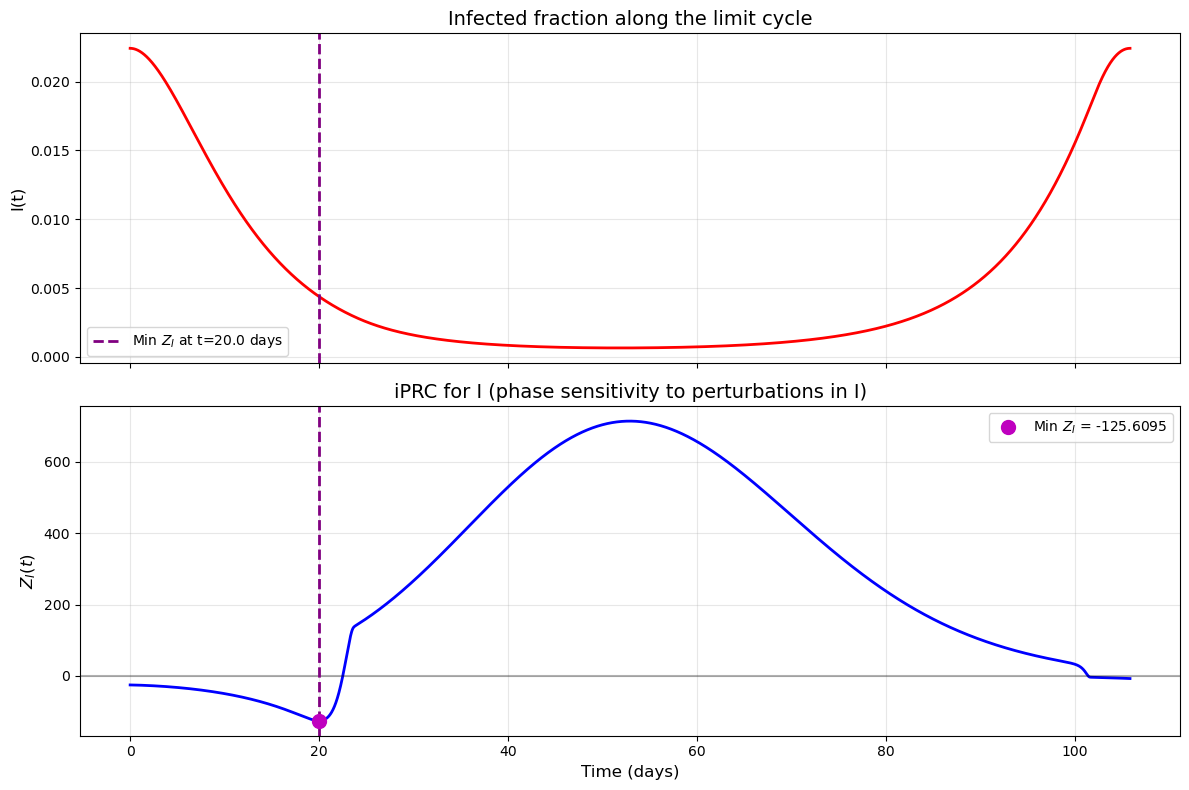

Z_I is minimum at t = 19.99 days
At this time:
  I = 0.004381
  Z_I = -125.609496

Interpretation: Perturbing I at t = 20.0 days causes the largest phase DELAY


In [22]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: I(t) along the limit cycle
ax1 = axes[0]
ax1.plot(Gamma.t, Gamma.I, 'r-', linewidth=2)
ax1.set_ylabel('I(t)', fontsize=12)
ax1.set_title('Infected fraction along the limit cycle', fontsize=14)
ax1.grid(True, alpha=0.3)

# Mark where Z_I is minimum
idx_min = np.argmin(Z.I)
t_min = Z.t[idx_min]
ax1.axvline(x=t_min, color='purple', linestyle='--', linewidth=2, label=f'Min $Z_I$ at t={t_min:.1f} days')
ax1.legend()

# Bottom: Z_I(t)
ax2 = axes[1]
ax2.plot(Z.t, Z.I, 'b-', linewidth=2)
ax2.set_xlabel('Time (days)', fontsize=12)
ax2.set_ylabel('$Z_I(t)$', fontsize=12)
ax2.set_title('iPRC for I (phase sensitivity to perturbations in I)', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)

# Mark the minimum
ax2.axvline(x=t_min, color='purple', linestyle='--', linewidth=2)
ax2.plot(t_min, Z.I[idx_min], 'mo', markersize=10, label=f'Min $Z_I$ = {Z.I[idx_min]:.4f}')
ax2.legend()

plt.tight_layout()
plt.savefig('I_and_Z_I_comparison.png', dpi=150)
plt.show()

# Print info
print(f"Z_I is minimum at t = {t_min:.2f} days")
print(f"At this time:")
print(f"  I = {Gamma.I[idx_min]:.6f}")
print(f"  Z_I = {Z.I[idx_min]:.6f}")
print(f"\nInterpretation: Perturbing I at t = {t_min:.1f} days causes the largest phase DELAY")